In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
import glob
import os
import numpy as np
import itertools
import ast
import datetime
import pandas as pd
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import warnings
from scipy.interpolate import griddata
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib as mpl
import iris

import iris.quickplot as qplt
import iris.plot as iplt
degree_sign= u'\N{DEGREE SIGN}'
import cmocean
import xarray as xr

def format_x_and_y_ticks(ax: plt.axes, xlocs: list, ylocs: list):
    """Format geoaxes ticks.

    Args:
        ax (plt.axes): axes
        xlocs (list): x locations
        ylocs (list): y locations

    Returns:
        ax: axes
    """

    # Make nicely formatted x- and y-ticks
    xlabels = []
    for j in range(len(xlocs)):
        if xlocs[j] > 0 :
            xlabels.append(f"{abs(xlocs[j]):.1f}{degree_sign}E")
        elif xlocs[j] == 0:
            xlabels.append(f"{abs(xlocs[j]):.0f}{degree_sign}")
        else:
            xlabels.append(f"{abs(xlocs[j]):.1f}{degree_sign}W")
            
    ax.set_xticks(xlocs)
    ax.set_xticklabels(xlabels)

    ylabels = []
    for j in range(len(ylocs)):
        if ylocs[j] < 0 :
            ylabels.append(f"{abs(ylocs[j]):.1f}{degree_sign}S")
        elif ylocs[j] == 0:
            ylabels.append(f"{abs(ylocs[j]):.0f}{degree_sign}")
        else:
            ylabels.append(f"{ylocs[j]:.1f}{degree_sign}N")
    ax.set_yticks(ylocs)
    ax.set_yticklabels(ylabels)
    ax.grid(linewidth=0.3)
    ax.set_xlabel("")
    ax.set_ylabel("")

    return ax

def circ_mean(h):
    return (np.arctan2(np.sin(2*np.pi*h/24).mean(),np.cos(2*np.pi*h/24).mean()) * 24/(2*np.pi)) % 24

In [25]:
files = glob.glob("/gws/ssde/j25a/ncas_climate/vol1/users/ekarl20/data/hackathon_monsoon_data/n2560_RAL3p3_tuned/*.csv")

dfs = []

for file in files:
    dfs.append(pd.read_csv(file))

df = pd.concat(dfs)
df["timestamp"] = pd.to_datetime(df.timestamp)

In [26]:
df.groupby("storm_id").size()

storm_id
405        1
406        3
407        1
408        1
409        2
          ..
1017973    3
1017974    3
1017975    1
1017976    1
1017977    1
Length: 954587, dtype: int64

In [13]:
df.columns

Index(['storm_id', 'life', 'area', 'Initial_UTC', 'Final_UTC', 'lon', 'lat',
       'u', 'v', 'pr_mean', 'pr_max', 'pr_perc90', 'min_BT', 'mean_BT',
       'timestamp'],
      dtype='object')

In [27]:
seasons = {"OND": [10,11,12],
          "JJAS": [6,7,8,9],
          "JF": [1,2],
          "MAM": [3,4,5]}

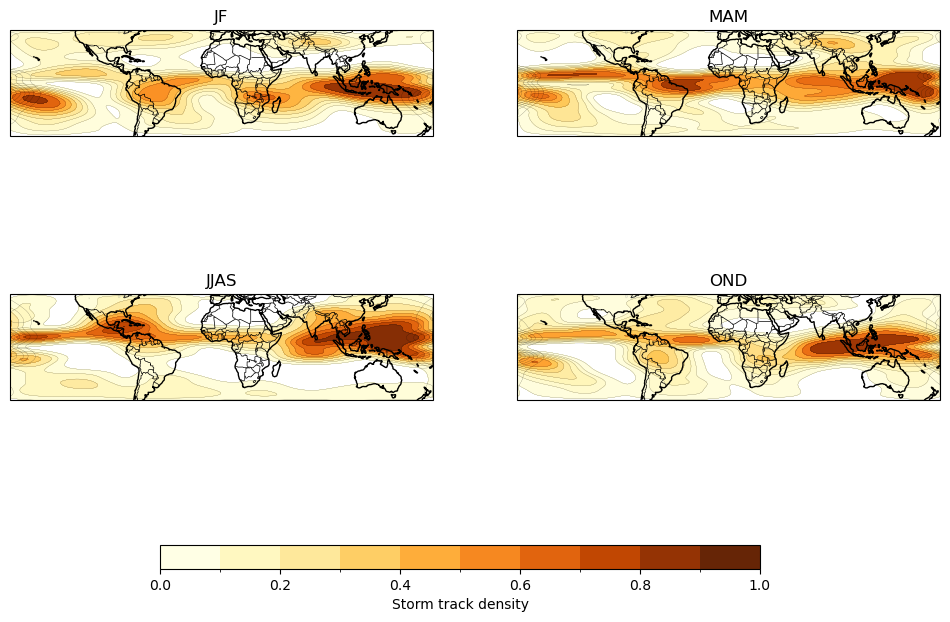

In [30]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

extent = [30.0, 35.5, -3.5, 1.5]
xlocs = [31.5, 33, 34.5]
ylocs = [-3,-1.5,0,1.5]

figsize=(6*2,6*2)

fig, axes = plt.subplots(2,2, figsize=figsize,subplot_kw=dict(projection=ccrs.PlateCarree(central_longitude=0)), facecolor="white")


cmap=plt.get_cmap("twilight")
bounds=np.arange(0,25,1)

norm = mpl.colors.BoundaryNorm(bounds, cmap.N)

# df_obs2 = df_obs.groupby("Storm").first()
# df2 = df.groupby("storm_id").first()

season_list = ["JF", "MAM", "JJAS", "OND"]

for i, ax in enumerate(axes.ravel()):
    season = season_list[i]
    ax.coastlines(resolution="110m")
    ax.set_extent([-180,180,-45,45])
    
    ax.add_feature(cfeature.BORDERS, edgecolor="black", linewidths=0.5)
    ax.add_feature(cfeature.LAKES, edgecolor="black", linewidths=0.5, alpha=0.1)
    
    df2 = df.groupby("storm_id").first()
    df2 = df2[df2.timestamp.dt.month.isin(seasons[season])]
    
    kde1 = sns.kdeplot(x=df2.lon,  y=df2.lat, ax=ax, fill=True, cmap="YlOrBr", alpha=1)
    
    kde = sns.kdeplot(x=df2.lon,  y=df2.lat, ax=ax, fill=False, color="black",
                        linewidths=0.1)
    ax.set_title(season)
    
    
    # sc = ax.scatter(df2.lon, df2.lat, c=df2.eat_hours, cmap=cmap, norm=norm, s=10, transform=ccrs.PlateCarree())
    
    # ax.set_title(extents[storm_type]['label'], color=extents[storm_type]['color'])
    
    ax.set_xlabel("")
    ax.set_ylabel("")


cmap = mpl.cm.YlOrBr
bounds = np.arange(0.,1.01,0.1)
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)

cbar_ax = fig.add_axes([0.25, 0.20, 0.5, 0.02])   # [left, bottom, width, height]

cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax, orientation='horizontal')
cbar.set_label("Storm track density")

plt.subplots_adjust(hspace=-0.6)

plt.show()